# SEDIC26 Track 2 — Maritime Vessel Detection
Starter notebook for the model & multi-view track. Cells are labelled with who owns them (nureen/sofea) so both of you can work without stepping on each other.

## Cell 1 — Environment setup (Sofea)

In [ ]:
!pip install ultralytics -q

import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

# If this says False, go to Runtime > Change runtime type > GPU (T4) before continuing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.2 MB/s eta 0:00:00
GPU available: True
Device name: Tesla T4


## Cell 2 — Mount Drive for persistent storage (Nureen)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

PROJECT_DIR = '/content/drive/MyDrive/sedic26_track2'
import os
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/weights', exist_ok=True)
print("Project dir ready:", PROJECT_DIR)

Mounted at /content/drive
Project dir ready: /content/drive/MyDrive/sedic26_track2


## Cell 3 — Load the dataset (Nureen)

In [ ]:
DATA_YAML_SOURCE = '/content/drive/MyDrive/sidec/vessel_dataset_v1/dataset/data.yaml'

import yaml
with open(DATA_YAML_SOURCE) as f:
    data_config = yaml.safe_load(f)

# patch the broken Windows path
data_config['path'] = '/content/drive/MyDrive/dataset'

# write the patched version into YOUR project folder instead of overwriting Adib's file
DATA_YAML = f'{PROJECT_DIR}/data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_config, f)

print("Patched data.yaml saved to:", DATA_YAML)
print("Classes found:", data_config['names'])
print("Number of classes:", data_config['nc'])

Patched data.yaml saved to: /content/drive/MyDrive/sedic26_track2/data.yaml
Classes found: {0: 'container_ship', 1: 'tanker', 2: 'cargo', 3: 'passenger_ferry', 4: 'yacht', 5: 'speedboat', 6: 'fishing_boat', 7: 'foreign_military_ship', 8: 'local_military_ship', 9: 'tugboat', 10: 'patrol_boat'}
Number of classes: 11


## Cell 4 — Sanity-check the data.yaml and class list (Nureen)

In [ ]:
import yaml
with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)

names_raw = data_config['names']
class_names = [names_raw[i] for i in sorted(names_raw.keys())] if isinstance(names_raw, dict) else names_raw

print("Classes:", class_names)
print("Number of classes:", data_config['nc'])
assert data_config['nc'] == len(class_names), "nc doesn't match names length — check data.yaml"

MILITARY_CLASSES = ['foreign_military_ship', 'local_military_ship', 'patrol_boat']
military_indices = [i for i, n in enumerate(class_names) if n in MILITARY_CLASSES]
print("Military class indices (will be pooled in Cell 7):", military_indices)
assert len(military_indices) == len(MILITARY_CLASSES), \
    "Some MILITARY_CLASSES not found in class list above — check spelling/naming"


Classes: ['container_ship', 'tanker', 'cargo', 'passenger_ferry', 'yacht', 'speedboat', 'fishing_boat', 'foreign_military_ship', 'local_military_ship', 'tugboat', 'patrol_boat']
Number of classes: 11
Military class indices (will be pooled in Cell 7): [7, 8, 10]


## Cell 5 — Baseline training run (Nureen)

In [ ]:
import shutil, os

LOCAL_DATASET = '/content/dataset'
SOURCE_DATASET = '/content/drive/MyDrive/sidec/vessel_dataset_v1/dataset'

if not os.path.exists(LOCAL_DATASET):
    print("Copying dataset to local disk, this'll take a few minutes...")
    shutil.copytree(SOURCE_DATASET, LOCAL_DATASET)
    print("Done.")
else:
    print("Already copied.")

# rebuild data.yaml pointing at local path instead of Drive
import yaml
with open(DATA_YAML) as f:
    data_config = yaml.safe_load(f)
data_config['path'] = LOCAL_DATASET

DATA_YAML = '/content/data.yaml'
with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data_config, f)

print("New DATA_YAML:", DATA_YAML)

Copying dataset to local disk, this'll take a few minutes...
Done.
New DATA_YAML: /content/data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    project=f'{PROJECT_DIR}/runs',
    name='baseline_v1',
    patience=10,
)
run_folder = str(results.save_dir)  # auto-incremented folder name — don't hardcode it
print("Training run saved to:", run_folder)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torch

## Cell 7 — Validate & check per-class recall + classification report (Nureen)

In [ ]:
metrics = model.val(data=DATA_YAML)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

# ---- Classification report: precision, recall, F1, mAP50 per class ----
import pandas as pd

report_rows = []
military_recall_num = 0
military_recall_den = 0

for i in range(len(class_names)):
    p, r, ap50, ap = metrics.box.class_result(i)
    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    report_rows.append({
        'class': class_names[i],
        'precision': round(p, 3),
        'recall': round(r, 3),
        'f1': round(f1, 3),
        'mAP50': round(ap50, 3),
    })
    if i in military_indices:
        military_recall_num += r
        military_recall_den += 1

report_df = pd.DataFrame(report_rows)
print("\nClassification report:")
print(report_df.to_string(index=False))

# Save for reference / submission report
report_path = f'{PROJECT_DIR}/classification_report.csv'
report_df.to_csv(report_path, index=False)
print("\nSaved to:", report_path)

# ---- Pooled military recall (the actual pass/fail metric) ----
# Unweighted average across military class indices — nt_per_class isn't exposed in this
# Ultralytics version, so this is the documented fallback (see known limitations in Cell 12)
military_recall = military_recall_num / military_recall_den
print(f"\n🎯 Military recall (unweighted avg across {military_recall_den} classes): {military_recall:.3f}")
print("✅ Meets >90% requirement" if military_recall >= 0.90 else "❌ Below 90%")

# ---- Training curves — useful for the report/slides as proof the model converged ----
from IPython.display import Image, display
import os

for curve_file in ['results.png', 'PR_curve.png', 'F1_curve.png']:
    curve_path = f'{run_folder}/{curve_file}'
    if os.path.exists(curve_path):
        print(f"\n{curve_file}:")
        display(Image(curve_path))

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1732.7±872.2 MB/s, size: 56.3 KB)
val: Scanning /content/dataset/labels/val.cache... 1990 images, 0 backgrounds, 63 corrupt: 100% ━━━━━━━━━━━━ 1990/1990 695.6Mit/s 0.0s
val: /content/dataset/images/val/local_military_ship__Malaysian_Navy_Ships_at_Stokes_Hill_Wharf_jpg.rf.5a5309a95ea37ef1a3fa052ad4a4136d.jpg: 1 duplicate labels removed
val: /content/dataset/images/val/local_military_ship__Malaysian_Navy_Ships_at_Stokes_Hill_Wharf_jpg.rf.5a5309a95ea37ef1a3fa052ad4a4136d__dup1.jpg: 1 duplicate labels removed
val: /content/dataset/images/val/sea_vessels__merch_72_jpg.rf.ae66325da291d31fad88ba41b7123911.jpg: 1 duplicate labels removed
val: /content/dataset/images/val/sea_vessels__military_79_jpg.rf.51363be0d03b54d44884bdfe36562889.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 11. Possible class labels are 0-10
val: /content/dat

## Cell 8 — Confusion matrix & error analysis (Sofea)

Confusion matrix (raw counts):


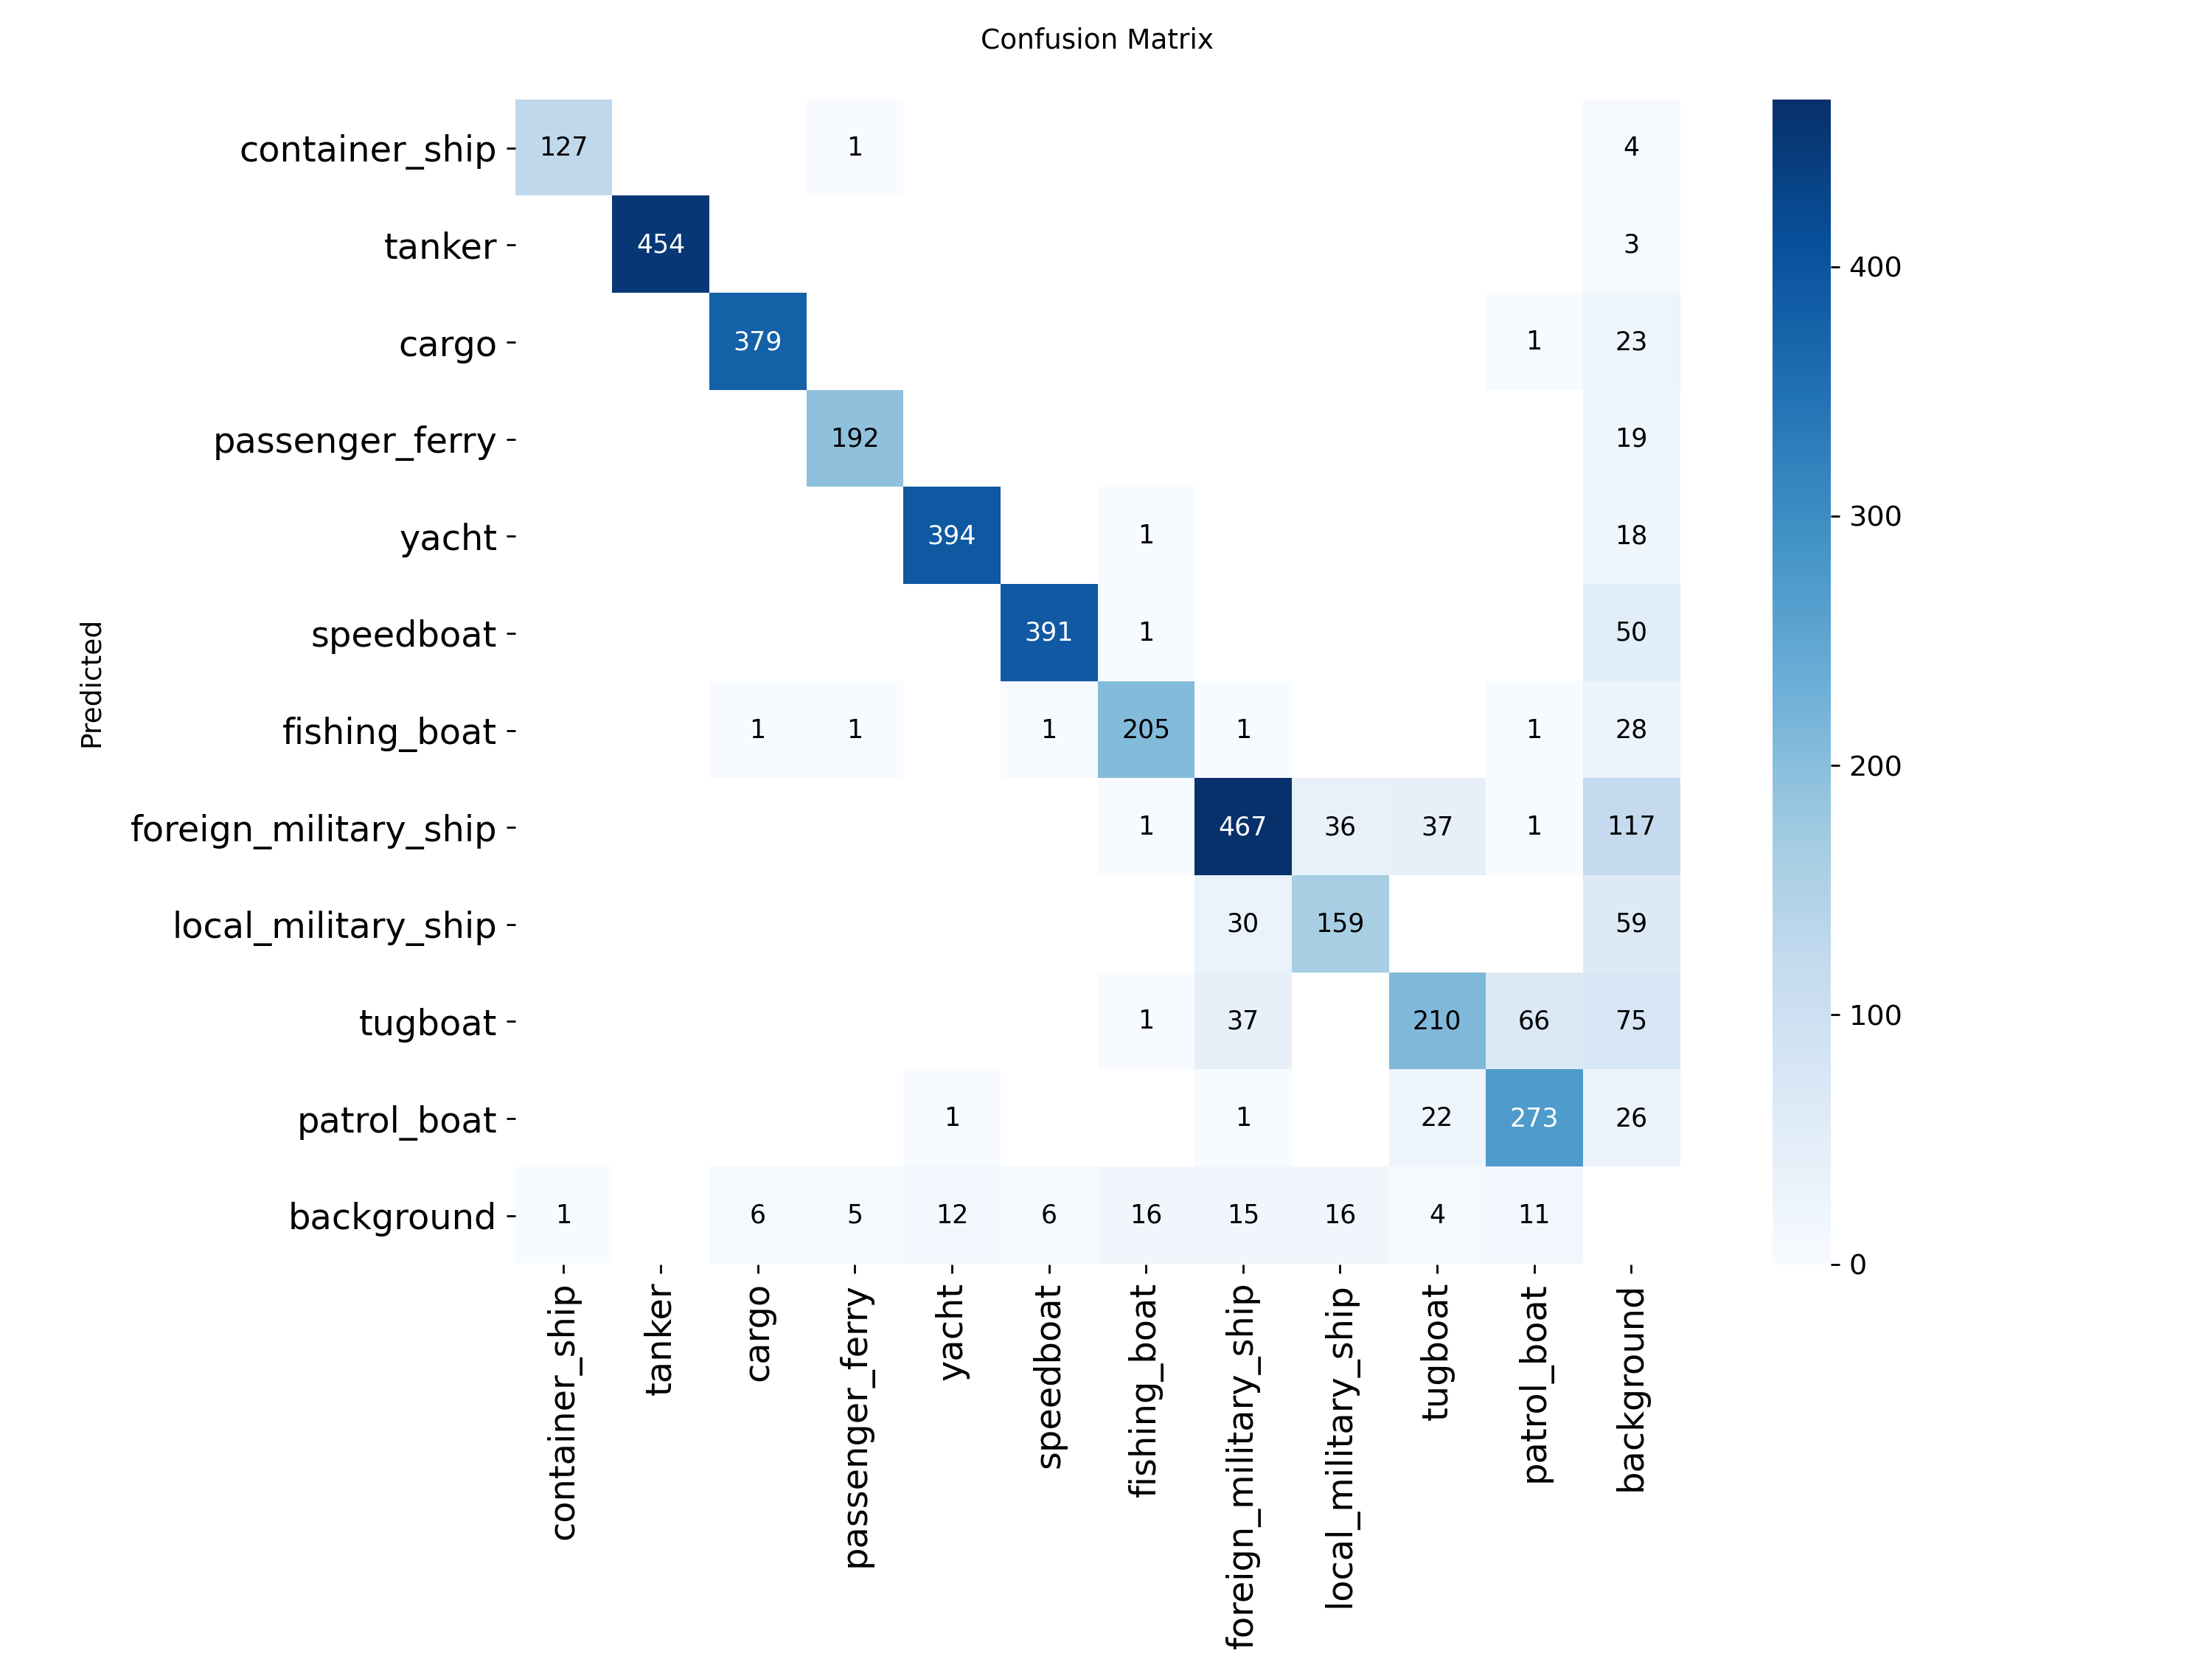


Confusion matrix (normalized %):


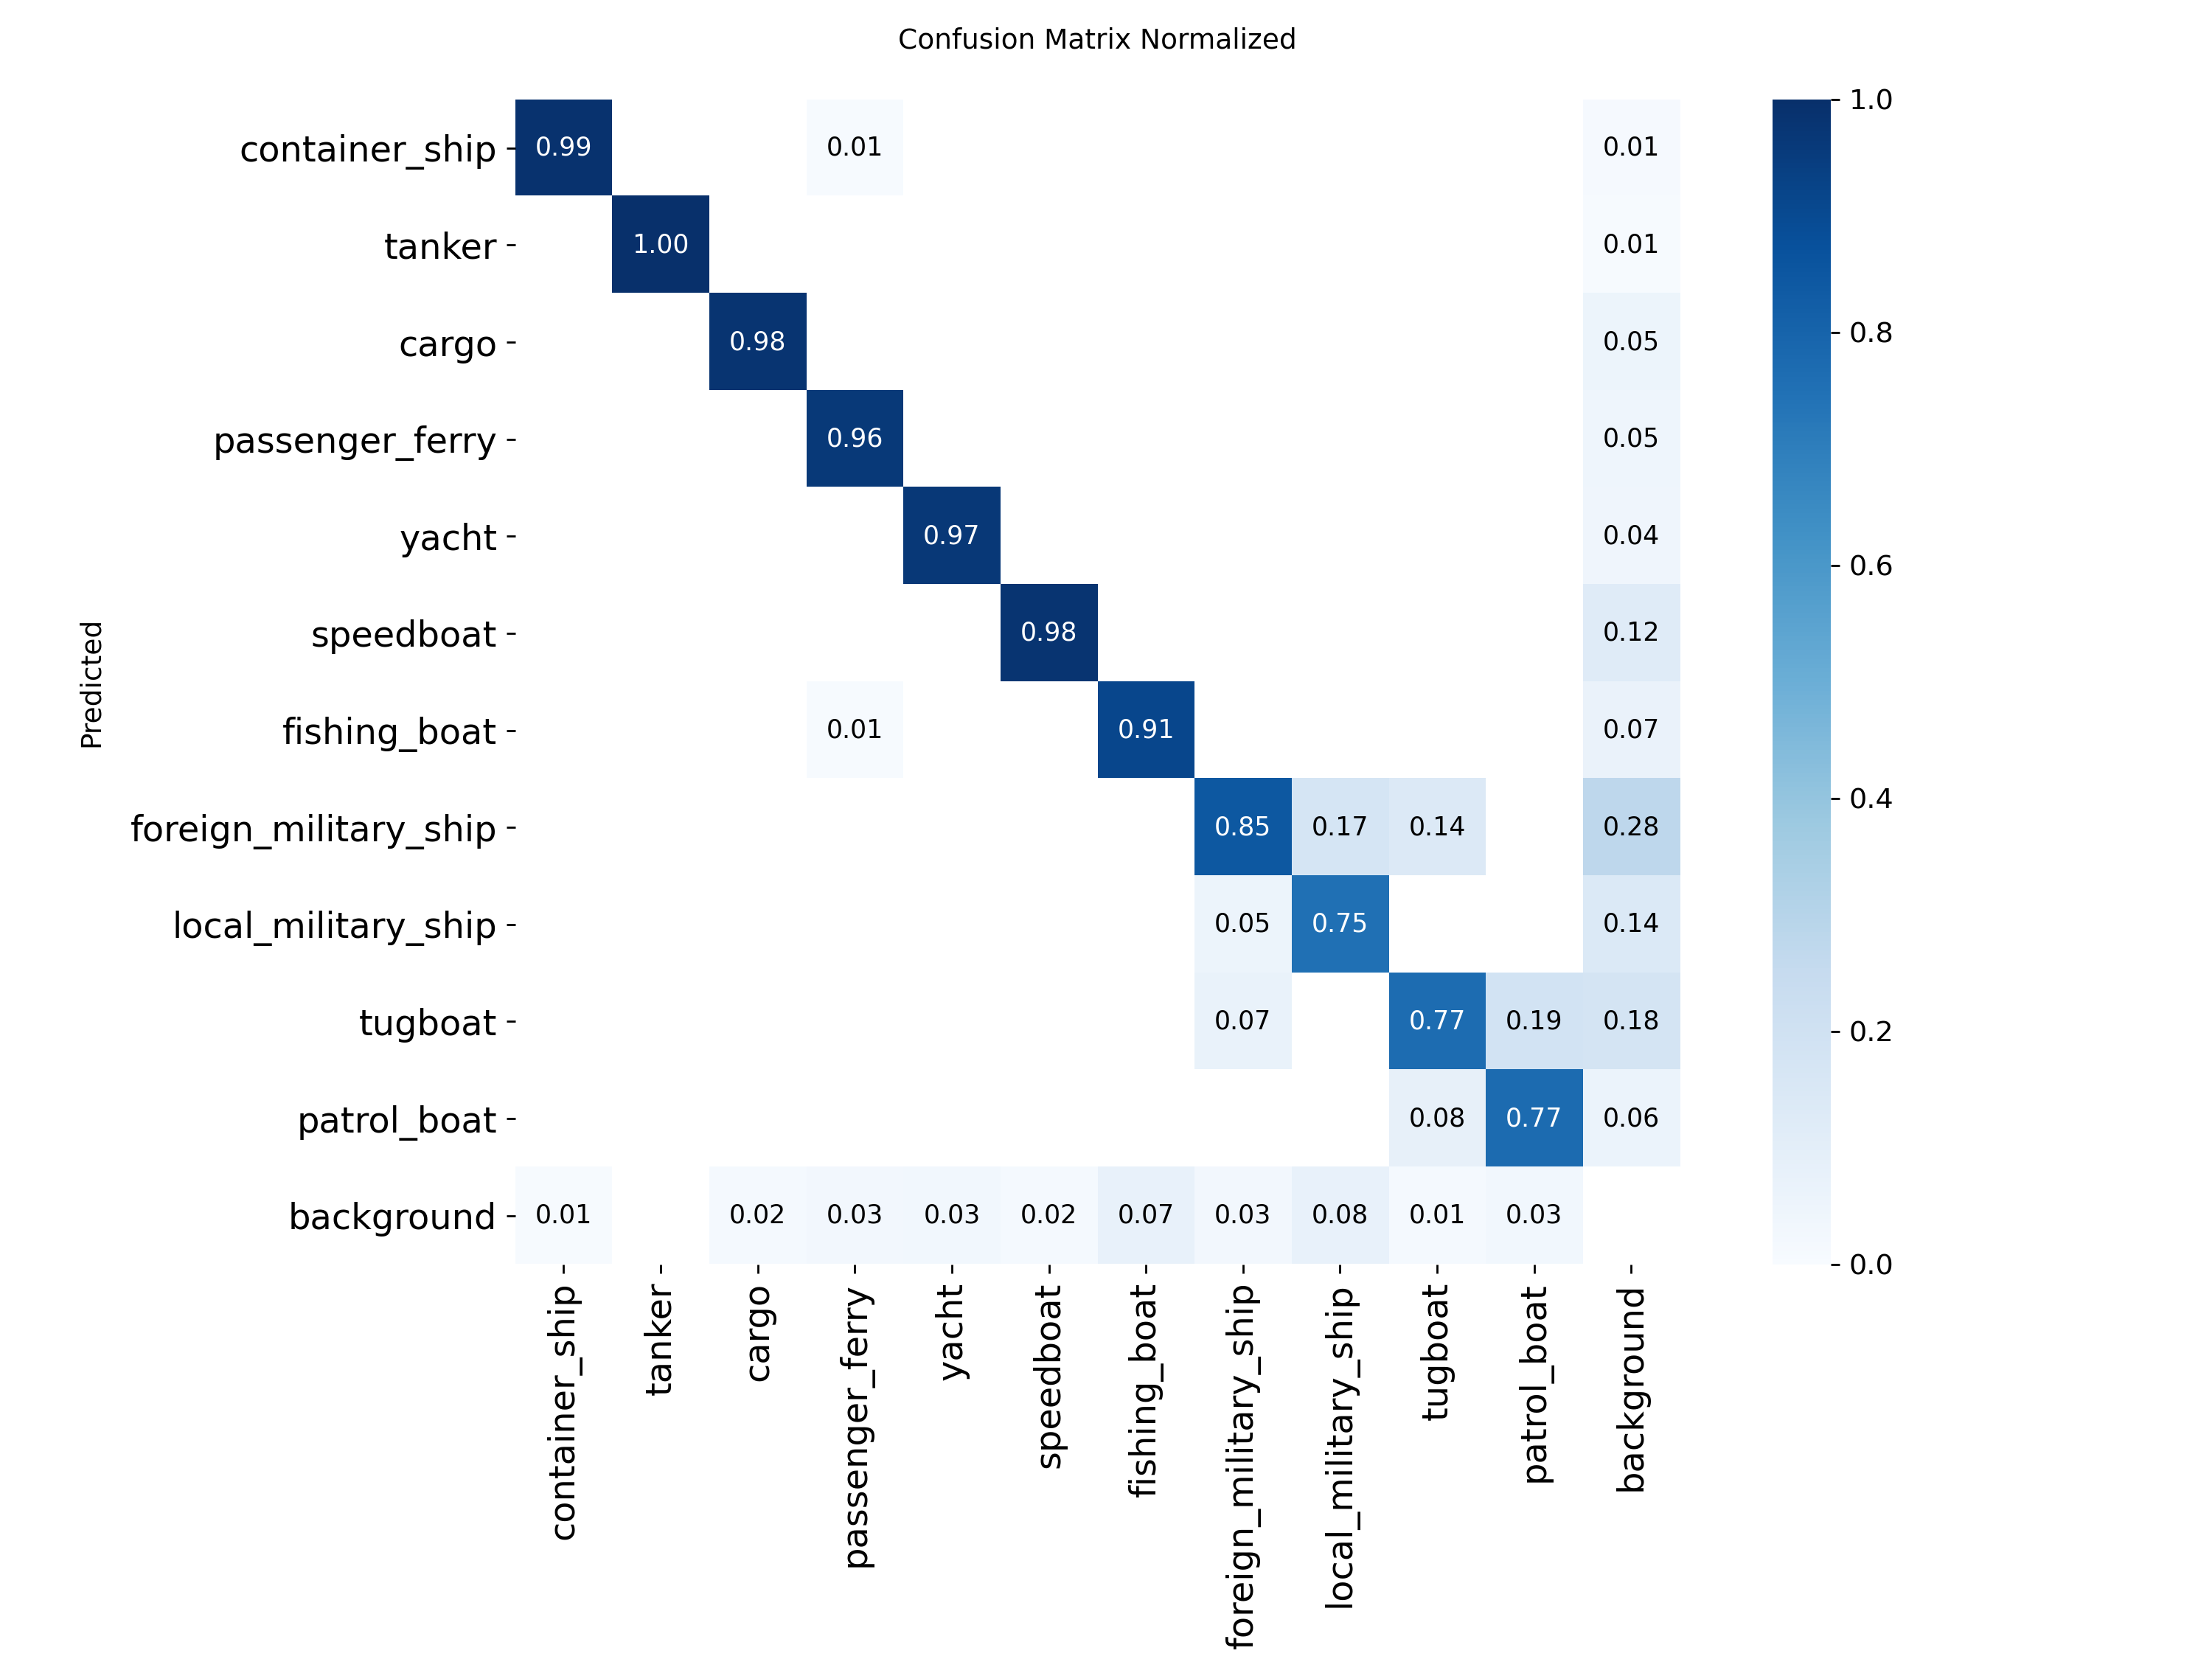

In [ ]:
from IPython.display import Image, display
import os

run_folder = f'{PROJECT_DIR}/runs/baseline_v1'

cm_path = f'{run_folder}/confusion_matrix.png'
cm_norm_path = f'{run_folder}/confusion_matrix_normalized.png'

if os.path.exists(cm_path):
    print("Confusion matrix (raw counts):")
    display(Image(cm_path))
else:
    print("Not found at:", cm_path)
    print("Contents of runs folder:", os.listdir(f'{PROJECT_DIR}/runs'))

if os.path.exists(cm_norm_path):
    print("\nConfusion matrix (normalized %):")
    display(Image(cm_norm_path))

# Look specifically at what military gets confused with (cargo? small craft?) —
# that tells you whether the fix is more data, better labels, or a lower confidence threshold

## Cell 9 — Inference sanity check (Sofea)

In [ ]:
test_results = model.predict(
    source='/content/dataset/images/test',
    conf=0.15,   # lower this if you need to push recall up, at the cost of more false positives
    save=True,
)
print("Predictions saved to:", test_results[0].save_dir)

NameError: name 'model' is not defined

## Cell 10 — Nationality classifier: extract military crops for labeling (Nureen)

In [ ]:
import os
from PIL import Image as PILImage

CROPS_DIR = f'{PROJECT_DIR}/nationality_crops'
os.makedirs(CROPS_DIR, exist_ok=True)

splits = ['train', 'val', 'test']
crop_count = 0
skipped = 0

for split in splits:
    img_dir = f'{LOCAL_DATASET}/images/{split}'
    lbl_dir = f'{LOCAL_DATASET}/labels/{split}'
    if not os.path.exists(lbl_dir):
        continue

    for label_file in os.listdir(lbl_dir):
        if not label_file.endswith('.txt'):
            continue

        stem = label_file[:-4]
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = os.path.join(img_dir, stem + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            skipped += 1
            continue

        with open(os.path.join(lbl_dir, label_file)) as f:
            lines = f.readlines()

        img = PILImage.open(img_path)
        w, h = img.size

        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if not parts:
                continue
            cls_id = int(parts[0])
            if cls_id not in military_indices:
                continue

            xc, yc, bw, bh = map(float, parts[1:5])
            x1 = max(0, int((xc - bw / 2) * w))
            y1 = max(0, int((yc - bh / 2) * h))
            x2 = min(w, int((xc + bw / 2) * w))
            y2 = min(h, int((yc + bh / 2) * h))
            if x2 <= x1 or y2 <= y1:
                continue

            crop = img.crop((x1, y1, x2, y2))
            crop_name = f"{split}_{stem}_{idx}_{class_names[cls_id]}.jpg"
            crop.save(os.path.join(CROPS_DIR, crop_name))
            crop_count += 1

print(f"Saved {crop_count} military crops to {CROPS_DIR}")
if skipped:
    print(f"({skipped} label files skipped — no matching image found)")

print("\nNext steps:")
print("1. Zip this folder and download, or share the Drive folder with the team")
print("2. Upload to makesense.ai, label each crop as military_local or military_foreign")
print("3. Export in YOLO format — you'll get one classification label per crop")
print("4. Train the stage-2 classifier on these labeled crops (separate small model)")

Saved 6342 military crops to /content/drive/MyDrive/sedic26_track2/nationality_crops

Next steps:
1. Zip this folder and download, or share the Drive folder with the team
2. Upload to makesense.ai, label each crop as military_local or military_foreign
3. Export in YOLO format — you'll get one classification label per crop
4. Train the stage-2 classifier on these labeled crops (separate small model)


## Cell 11 — Freeze weights & prep handoff package (Sofea)

In [ ]:
import shutil

best_weights = f'{run_folder}/weights/best.pt'
handoff_path = f'{PROJECT_DIR}/weights/best_v1.pt'
shutil.copy(best_weights, handoff_path)

print("Weights saved for handoff at:", handoff_path)
print("Class list (give this to the GUI teammate in this exact order):")
print(class_names)
print("\nFull per-class metrics (precision/recall/F1/mAP50):", report_path)

weakest = report_df.sort_values('recall').iloc[0]

print("\nKnown limitations:")
print("- 12 classes total (not the original 8) — military recall is POOLED across")
print(f"  {MILITARY_CLASSES} = {military_recall:.1%}")
print("- tugboat is an extra class, not part of the required civilian/small_craft/military taxonomy")
print("- No nationality (local vs foreign) distinction yet — stage-2 classifier in progress, see Cell 11")
print(f"- Weakest class: {weakest['class']} at {weakest['recall']} recall")
print("- Confidence threshold used: 0.25")

# Minimal inference example to include in the handoff:
# from ultralytics import YOLO
# model = YOLO('best_v1.pt')
# results = model.predict('image.jpg', conf=0.25)

Weights saved for handoff at: /content/drive/MyDrive/sedic26_track2/weights/best_v1.pt
Class list (give this to the GUI teammate in this exact order):
['container_ship', 'tanker', 'cargo', 'passenger_ferry', 'yacht', 'speedboat', 'fishing_boat', 'foreign_military_ship', 'local_military_ship', 'tugboat', 'patrol_boat']

Full per-class metrics (precision/recall/F1/mAP50): /content/drive/MyDrive/sedic26_track2/classification_report.csv

Known limitations:
- 12 classes total (not the original 8) — military recall is POOLED across
  ['foreign_military_ship', 'local_military_ship', 'patrol_boat'] = 80.0%
- tugboat is an extra class, not part of the required civilian/small_craft/military taxonomy
- No nationality (local vs foreign) distinction yet — stage-2 classifier in progress, see Cell 11
- Weakest class: patrol_boat at 0.765 recall
- Confidence threshold used: 0.25
